<a href="https://colab.research.google.com/github/Infranape1/AI_Music_Classification/blob/master/AI_MUsic_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install librosa
!pip install tensorflow
!pip install matplotlib
!pip install numpy
!pip install scikit-learn
!pip install seaborn

In [ ]:
import os
import librosa
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

os.listdir('/content/drive/MyDrive/GTZAN')

['genres']

In [ ]:
DATASET_PATH = "/content/drive/MyDrive/GTZAN/genres"

In [ ]:
def extract_mfcc(file_path, max_pad_len=130):
    try:
        audio, sr = librosa.load(file_path, duration=30)

        mfcc = librosa.feature.mfcc(
            y=audio,
            sr=sr,
            n_mfcc=40
        )

        # Padding
        pad_width = max_pad_len - mfcc.shape[1]
        if pad_width > 0:
            mfcc = np.pad(mfcc,
                          pad_width=((0,0),(0,pad_width)),
                          mode='constant')
        else:
            mfcc = mfcc[:, :max_pad_len]

        return mfcc

    except Exception as e:
        print("Error:", e)
        return None

In [ ]:
X = []
y = []

genres = os.listdir(DATASET_PATH)

for genre in genres:
    genre_path = os.path.join(DATASET_PATH, genre)

    for file in os.listdir(genre_path):
        file_path = os.path.join(genre_path, file)

        mfcc = extract_mfcc(file_path)
        if mfcc is not None:
            X.append(mfcc)
            y.append(genre)

X = np.array(X)
y = np.array(y)

print("Shape of X:", X.shape)

/tmp/ipykernel_1126/3989917295.py:3: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(file_path, duration=30)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Error: 
Shape of X: (999, 40, 130)


In [ ]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

In [ ]:
import pickle
pickle.dump(label_encoder, open("label_encoder.pkl", "wb"))

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42
)

In [ ]:
X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]

In [ ]:
model = models.Sequential([

    layers.Conv2D(32, (3,3), activation='relu', input_shape=(40,130,1)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    validation_data=(X_test, y_test),
    callbacks=[checkpoint, early_stop]
)

Epoch 1/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.2150 - loss: 4.5132
Epoch 1: val_accuracy improved from -inf to 0.23500, saving model to best_model.h5


25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 218ms/step - accuracy: 0.2174 - loss: 4.4671 - val_accuracy: 0.2350 - val_loss: 3.2570
Epoch 2/30
23/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4991 - loss: 1.4775
Epoch 2: val_accuracy did not improve from 0.23500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5000 - loss: 1.4725 - val_accuracy: 0.2050 - val_loss: 2.4612
Epoch 3/30
23/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5904 - loss: 1.1697
Epoch 3: val_accuracy did not improve from 0.23500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5941 - loss: 1.1640 - val_accuracy: 0.2250 - val_loss: 2.1743
Epoch 4/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7241 - loss: 0.8084
Epoch 4: val_accuracy improved from 0.23500 to 0.43000, saving model to best_model.h5


25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7240 - loss: 0.8081 - val_accuracy: 0.4300 - val_loss: 1.6025
Epoch 5/30
22/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7810 - loss: 0.6304
Epoch 5: val_accuracy improved from 0.43000 to 0.45500, saving model to best_model.h5


25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7807 - loss: 0.6334 - val_accuracy: 0.4550 - val_loss: 1.7551
Epoch 6/30
23/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8766 - loss: 0.3821
Epoch 6: val_accuracy did not improve from 0.45500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8757 - loss: 0.3838 - val_accuracy: 0.3800 - val_loss: 1.8704
Epoch 7/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8849 - loss: 0.3428
Epoch 7: val_accuracy improved from 0.45500 to 0.47000, saving model to best_model.h5


25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8849 - loss: 0.3434 - val_accuracy: 0.4700 - val_loss: 1.6604
Epoch 8/30
20/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9521 - loss: 0.1859
Epoch 8: val_accuracy improved from 0.47000 to 0.50500, saving model to best_model.h5


25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9486 - loss: 0.1939 - val_accuracy: 0.5050 - val_loss: 1.7246
Epoch 9/30
21/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9477 - loss: 0.1586
Epoch 9: val_accuracy did not improve from 0.50500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9467 - loss: 0.1616 - val_accuracy: 0.4300 - val_loss: 2.2164


In [ ]:
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

y_pred = np.argmax(model.predict(X_test), axis=1)

print(classification_report(y_test, y_pred))

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4186 - loss: 1.6413 
Test Accuracy: 0.4300000071525574
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 247ms/step
              precision    recall  f1-score   support

           0       0.30      0.43      0.35        21
           1       0.57      1.00      0.73        12
           2       0.39      0.54      0.46        24
           3       0.25      0.23      0.24        22
           4       0.35      0.47      0.40        15
           5       0.70      0.59      0.64        27
           6       1.00      0.28      0.43        18
           7       1.00      0.21      0.35        19
           8       0.35      0.64      0.45        22
           9       0.25      0.05      0.08        20

    accuracy                           0.43       200
   macro avg       0.52      0.44      0.41       200
weighted avg       0.51      0.43      0.41       200



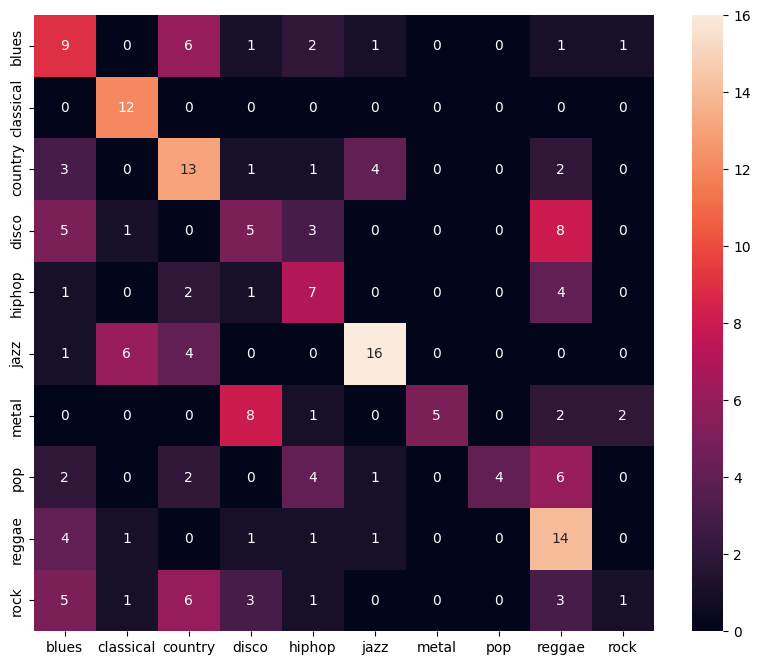

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.show()

In [ ]:
model.save("music_genre_model.h5")
model.export("music_genre_model_tf_savedmodel") # Save as TensorFlow SavedModel format by providing a directory name
pickle.dump(label_encoder, open("label_encoder.pkl","wb"))

Saved artifact at 'music_genre_model_tf_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 40, 130, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  135986468844176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135986468845328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135986468832464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135986468845520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135986468839376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135986468841680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135986468835344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135986468839760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135986468838416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135986468836304: TensorSpec(shape=(), dtype=tf.resource, name=None)
 

In [ ]:
pickle.dump(label_encoder, open("label_encoder.pkl","wb"))

In [ ]:
from google.colab import files

files.download("music_genre_model.h5")
files.download("label_encoder.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>